# Prophet — Wikipedia Page-Views Walkthrough
The classic Prophet getting-started example using log page-views for Peyton Manning.

This notebook covers the full workflow from raw data to interactive Plotly charts.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)
df["ds"] = pd.to_datetime(df["ds"])
print(f"Rows: {len(df)}  |  {df['ds'].min().date()} → {df['ds'].max().date()}")
df.head()

Rows: 2905  |  2007-12-10 → 2016-01-20


,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


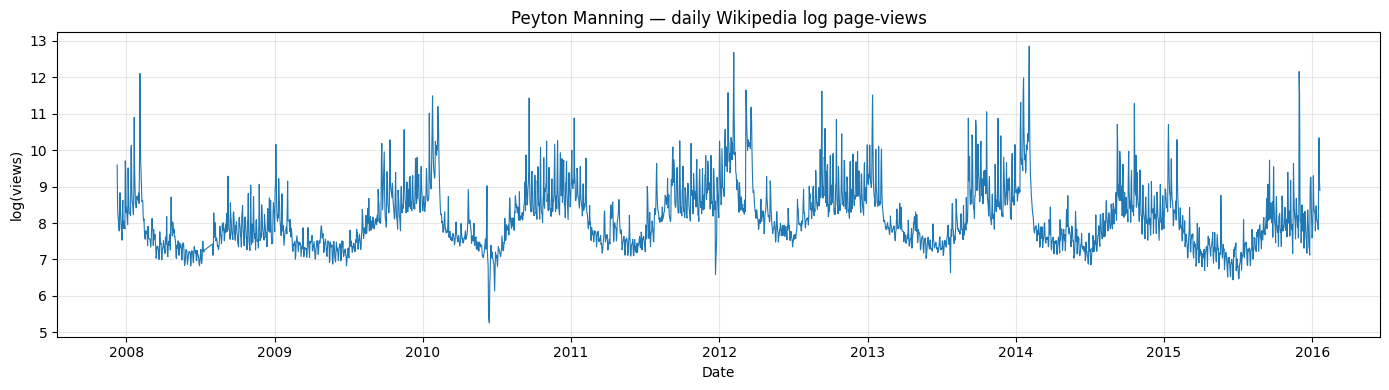

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df["y"], linewidth=0.8)
ax.set(title="Peyton Manning — daily Wikipedia log page-views",
       xlabel="Date", ylabel="log(views)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fit Default Model
`Prophet()` with all defaults enables automatic yearly and weekly seasonality.

In [4]:
m = Prophet()
m.fit(df)

08:17:32 - cmdstanpy - INFO - Chain [1] start processing


08:17:36 - cmdstanpy - INFO - Chain [1] done processing


## 3. Make Future DataFrame

In [5]:
future = m.make_future_dataframe(periods=365)
print(f"Future rows: {len(future)}  |  Last date: {future['ds'].max().date()}")
future.tail()

Future rows: 3270  |  Last date: 2017-01-19


,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


## 4. Predict

In [6]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
3260,2017-01-10,8.166629,7.406834,8.873821
3261,2017-01-11,8.004319,7.250124,8.688064
3262,2017-01-12,8.022265,7.259106,8.722042
3263,2017-01-13,8.047971,7.338006,8.778132
3264,2017-01-14,7.828293,7.072296,8.574767
3265,2017-01-15,8.210097,7.505171,8.965653
3266,2017-01-16,8.535122,7.776810,9.219834
3267,2017-01-17,8.322549,7.562348,9.077377
3268,2017-01-18,8.155179,7.418732,8.898024
3269,2017-01-19,8.167136,7.415203,8.832405


## 5. Forecast Plot

/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


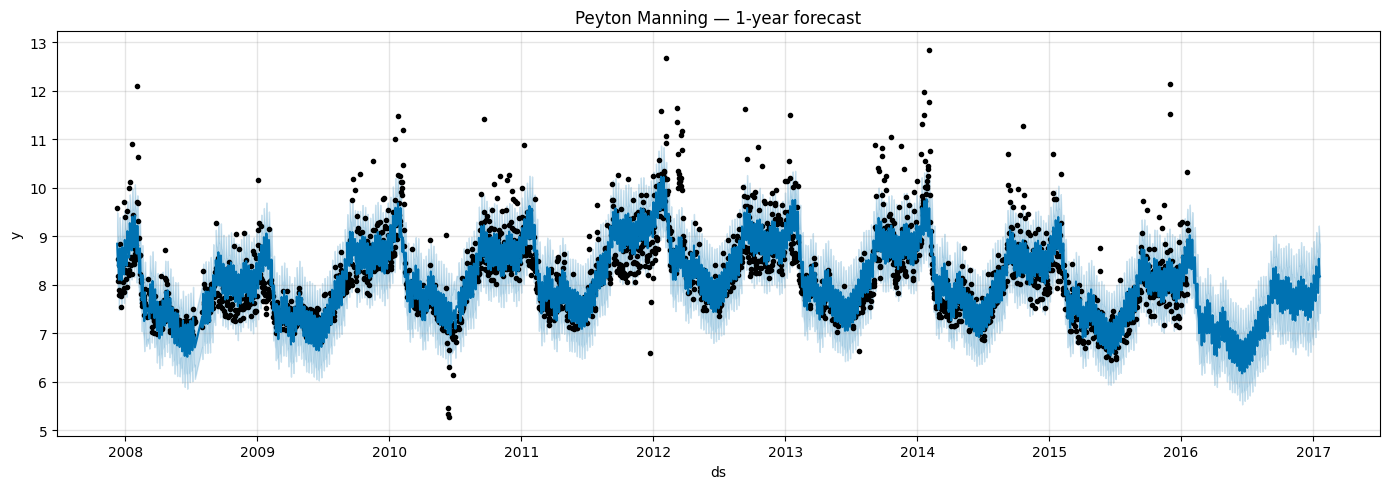

In [7]:
fig1 = m.plot(forecast)
fig1.set_size_inches(14, 5)
plt.title("Peyton Manning — 1-year forecast")
plt.tight_layout()
plt.show()

## 6. Component Decomposition
Shows trend + each seasonal component separately.

/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a

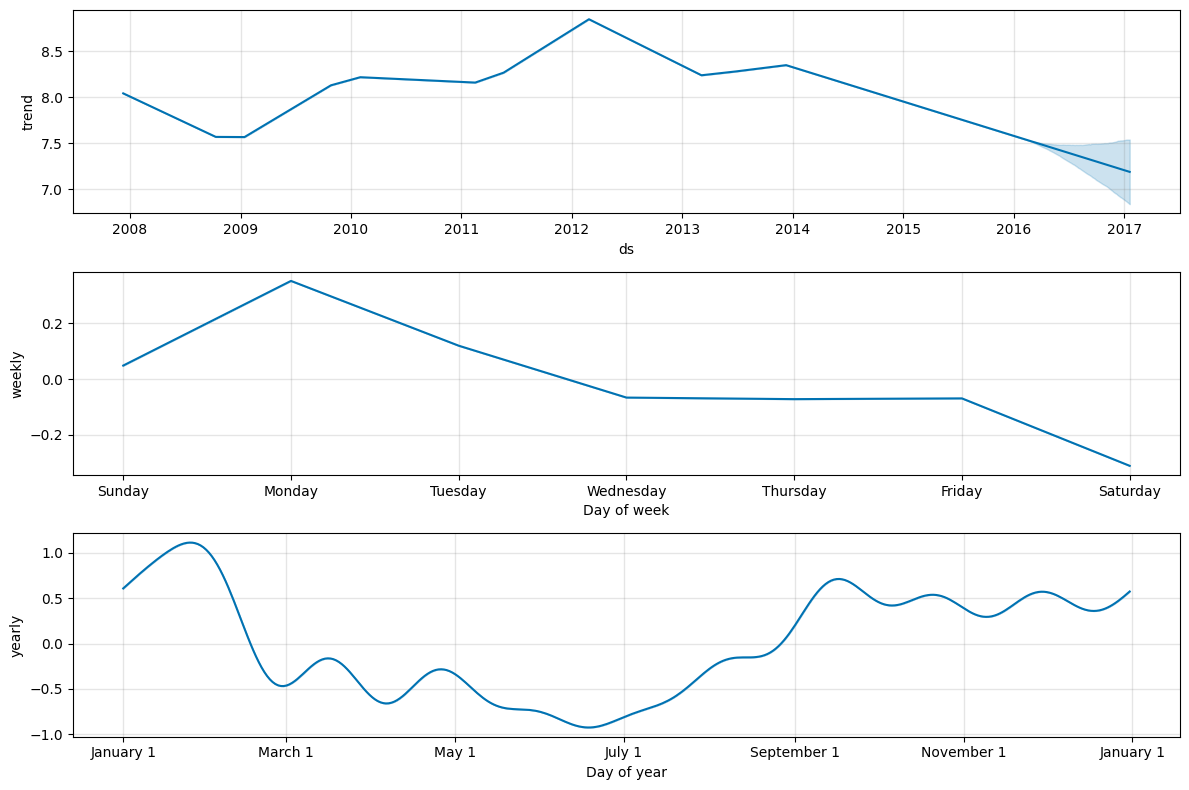

In [8]:
fig2 = m.plot_components(forecast)
fig2.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 7. Interactive Charts (Plotly)

In [9]:
plot_plotly(m, forecast)

In [10]:
plot_components_plotly(m, forecast)

## 8. Inspect Changepoints

/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/home/malam/.pyenv/versions/3.11.14/envs/spark3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



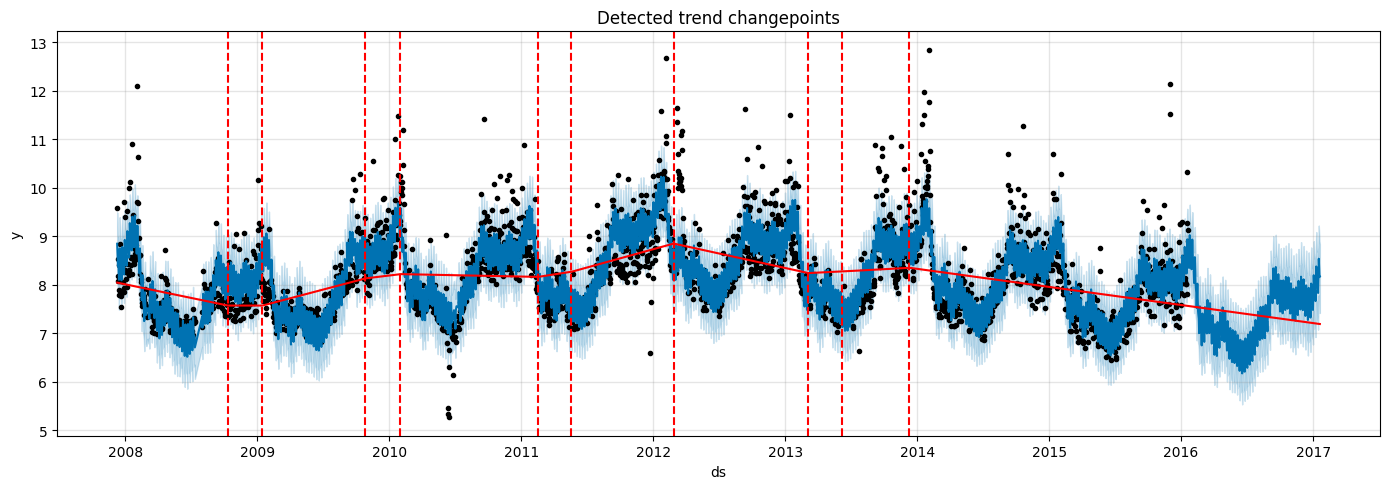

Top 5 changepoints (by magnitude):
changepoint    delta
 2013-03-05 0.459754
 2009-01-14 0.459242
 2008-10-11 0.352212
 2011-02-16 0.298224
 2011-05-20 0.211356


In [11]:
from prophet.plot import add_changepoints_to_plot

fig3 = m.plot(forecast)
fig3.set_size_inches(14, 5)
add_changepoints_to_plot(fig3.gca(), m, forecast)
plt.title("Detected trend changepoints")
plt.tight_layout()
plt.show()

import pandas as pd
cp = pd.DataFrame({
    "changepoint": m.changepoints,
    "delta":       m.params["delta"].mean(axis=0),
}).sort_values("delta", ascending=False)
print("Top 5 changepoints (by magnitude):")
print(cp.head(5).to_string(index=False))